# Modele BERT — Analyse de Sentiment Bancaire
**Objectif :** Utiliser FinBERT pour classifier les sentiments financiers.

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

print("Bibliotheques importees !")
print(f"PyTorch version : {torch.__version__}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device utilise : {device}")

Bibliotheques importees !
PyTorch version : 2.11.0+cpu
Device utilise : cpu


In [2]:
# Chargement
df = pd.read_csv(
    r'C:\Users\emman\Documents\Portfolio\sentiment-analysis-banking\data\data_cleaned.csv'
)

print(f"Dataset charge : {len(df)} lignes")
print(f"\nDistribution :")
print(df['Sentiment'].value_counts())

Dataset charge : 5841 lignes

Distribution :
Sentiment
neutral     3129
positive    1852
negative     860
Name: count, dtype: int64


In [3]:
# Charger le tokenizer et modele FinBERT
print("Telechargement de FinBERT en cours...")
print("(Cela peut prendre 2-3 minutes la premiere fois)")

MODEL_NAME = "ProsusAI/finbert"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
model = model.to(device)

print("FinBERT charge avec succes !")
print(f"Nombre de parametres : {sum(p.numel() for p in model.parameters()):,}")

Telechargement de FinBERT en cours...
(Cela peut prendre 2-3 minutes la premiere fois)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

FinBERT charge avec succes !
Nombre de parametres : 109,484,547


In [4]:
# Tester FinBERT sur quelques exemples
def predire_sentiment(texte):
    # Tokeniser le texte
    inputs = tokenizer(
        texte,
        return_tensors='pt',
        max_length=512,
        truncation=True,
        padding=True
    ).to(device)

    # Prediction
    with torch.no_grad():
        outputs = model(**inputs)

    # Convertir en probabilites
    probs = torch.softmax(outputs.logits, dim=1)
    pred  = torch.argmax(probs, dim=1).item()

    # FinBERT labels : 0=positive, 1=negative, 2=neutral
    labels = {0: 'positive', 1: 'negative', 2: 'neutral'}

    return {
        'sentiment': labels[pred],
        'positive' : f"{probs[0][0].item():.2%}",
        'negative' : f"{probs[0][1].item():.2%}",
        'neutral'  : f"{probs[0][2].item():.2%}"
    }

# Tests
exemples = [
    "The company reported strong profit growth this quarter",
    "The bank faces massive losses and may go bankrupt",
    "The company released its annual financial report"
]

print("Test de FinBERT sur des exemples :\n")
for texte in exemples:
    res = predire_sentiment(texte)
    print(f"Texte     : {texte}")
    print(f"Sentiment : {res['sentiment']}")
    print(f"Positive  : {res['positive']}")
    print(f"Negative  : {res['negative']}")
    print(f"Neutral   : {res['neutral']}")
    print("-" * 55)

Test de FinBERT sur des exemples :

Texte     : The company reported strong profit growth this quarter
Sentiment : positive
Positive  : 95.42%
Negative  : 1.69%
Neutral   : 2.89%
-------------------------------------------------------
Texte     : The bank faces massive losses and may go bankrupt
Sentiment : negative
Positive  : 0.89%
Negative  : 95.45%
Neutral   : 3.65%
-------------------------------------------------------
Texte     : The company released its annual financial report
Sentiment : neutral
Positive  : 2.79%
Negative  : 2.41%
Neutral   : 94.79%
-------------------------------------------------------


In [5]:
# Evaluation de FinBERT sur le dataset complet
print("Evaluation en cours...")
print("(Cela peut prendre 10-15 minutes sur CPU)")

# Mapping des labels FinBERT vers nos labels
finbert_to_label = {
    'positive': 2,
    'negative': 0,
    'neutral' : 1
}

y_true = []
y_pred = []

for i, row in df.iterrows():
    res    = predire_sentiment(row['Sentence'])
    pred   = finbert_to_label[res['sentiment']]
    y_pred.append(pred)
    y_true.append(row['label'])

    # Afficher la progression
    if (i + 1) % 500 == 0:
        print(f"Traite : {i + 1}/{len(df)} textes...")

print("Evaluation terminee !")

# Accuracy
acc = accuracy_score(y_true, y_pred)
print(f"\nAccuracy FinBERT : {acc:.4f}")
print(f"\nRapport detaille :")
print(classification_report(
    y_true,
    y_pred,
    target_names=['negative', 'neutral', 'positive']
))

Evaluation en cours...
(Cela peut prendre 10-15 minutes sur CPU)
Traite : 500/5841 textes...
Traite : 1000/5841 textes...
Traite : 1500/5841 textes...
Traite : 2000/5841 textes...
Traite : 2500/5841 textes...
Traite : 3000/5841 textes...
Traite : 3500/5841 textes...
Traite : 4000/5841 textes...
Traite : 4500/5841 textes...
Traite : 5000/5841 textes...
Traite : 5500/5841 textes...
Evaluation terminee !

Accuracy FinBERT : 0.7581

Rapport detaille :
              precision    recall  f1-score   support

    negative       0.51      0.82      0.63       860
     neutral       0.82      0.75      0.78      3129
    positive       0.87      0.75      0.80      1852

    accuracy                           0.76      5841
   macro avg       0.73      0.77      0.74      5841
weighted avg       0.79      0.76      0.77      5841



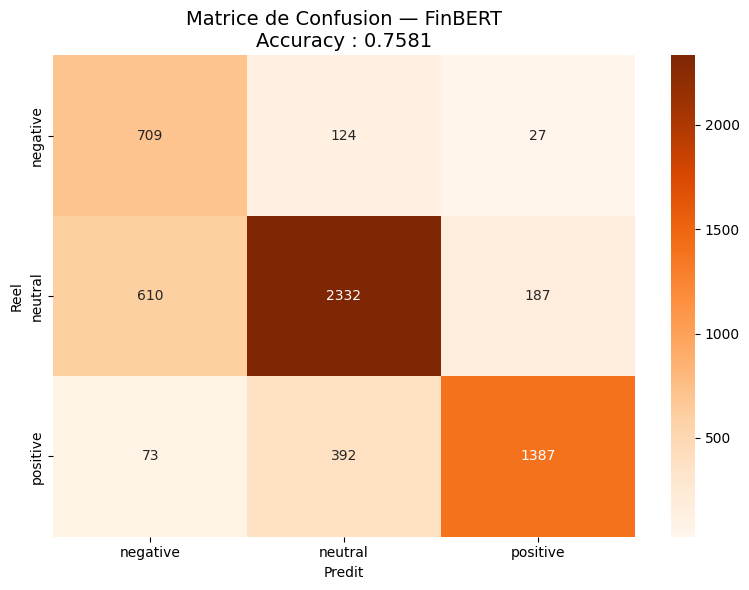

Graphique sauvegarde !


In [6]:
# Matrice de confusion FinBERT
label_names = ['negative', 'neutral', 'positive']

fig, ax = plt.subplots(figsize=(8, 6))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Oranges',
    ax=ax,
    xticklabels=label_names,
    yticklabels=label_names
)
ax.set_title(
    f'Matrice de Confusion — FinBERT\nAccuracy : 0.7581',
    fontsize=14
)
ax.set_ylabel('Reel')
ax.set_xlabel('Predit')

plt.tight_layout()
plt.savefig(
    '../reports/06_confusion_matrix_finbert.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()
print("Graphique sauvegarde !")

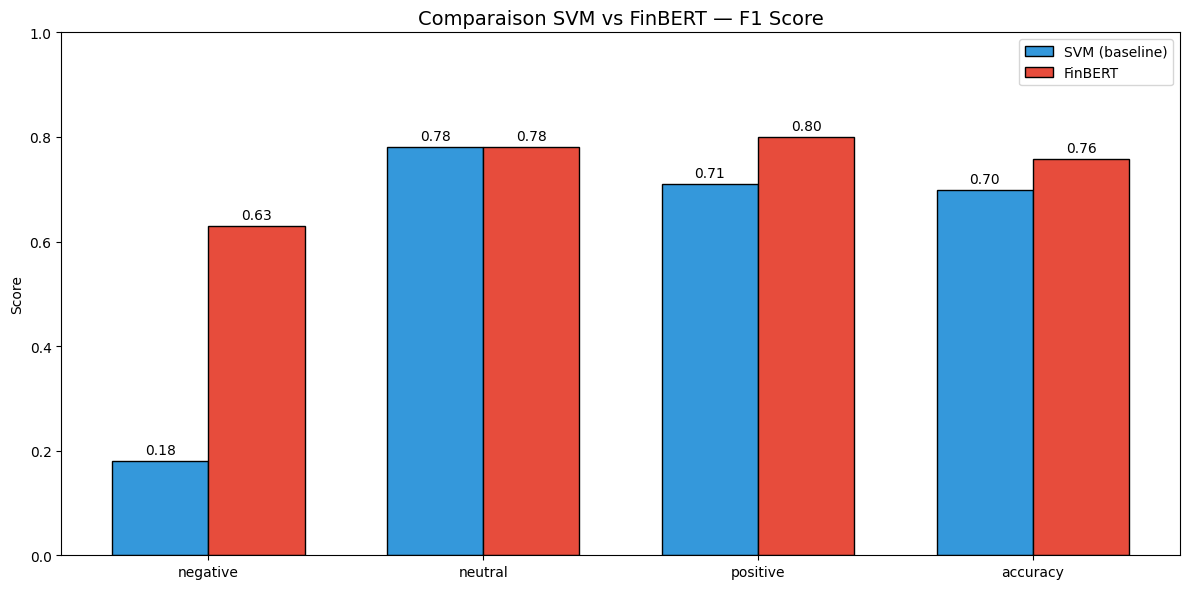

Graphique sauvegarde !


In [7]:
# Comparaison visuelle Baseline vs FinBERT
categories = ['negative', 'neutral', 'positive', 'accuracy']

svm_scores     = [0.18, 0.78, 0.71, 0.699]
finbert_scores = [0.63, 0.78, 0.80, 0.758]

x     = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(x - width/2, svm_scores,     width,
       label='SVM (baseline)',
       color='#3498db', edgecolor='black')
ax.bar(x + width/2, finbert_scores, width,
       label='FinBERT',
       color='#e74c3c', edgecolor='black')

ax.set_title(
    'Comparaison SVM vs FinBERT — F1 Score',
    fontsize=14
)
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.0)
ax.legend()

for bars in ax.containers:
    ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=10)

plt.tight_layout()
plt.savefig(
    '../reports/07_comparaison_svm_finbert.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()
print("Graphique sauvegarde !")